# From Byte to Beat: Auditing Cardiovascular Risk Before Modeling It

A data-quality-first Byte2Beat workflow where plausibility checks, calibration, and failure-mode analysis matter as much as AUROC.

Author: Yaroslav Kholmirzayev

This notebook is the public, submission-facing evidence flow. It reads generated artifacts by default so judges can review the analysis quickly. Set `RUN_FULL_PIPELINE = True` in the setup cell to regenerate all artifacts from raw local data.

In [1]:
from pathlib import Path
import os
import subprocess
import sys
import urllib.request
import zipfile

import pandas as pd
from IPython.display import Image, display, Markdown

RELEASE_ZIP_URL = 'https://github.com/qu1nty9/Byte2Beat-Kaggle-Hackathon/archive/refs/tags/v1.0.0-kaggle-submission.zip'

def locate_project_root() -> Path:
    root = Path.cwd().resolve()
    while not (root / 'scripts/check_submission_assets.py').exists() and root.parent != root:
        root = root.parent
    if (root / 'scripts/check_submission_assets.py').exists():
        return root

    cache_root = Path('/kaggle/working/byte2beat_release') if Path('/kaggle/working').exists() else Path.cwd() / '.byte2beat_release'
    cache_root.mkdir(parents=True, exist_ok=True)
    zip_path = cache_root / 'byte2beat_release.zip'
    candidates = [cache_root] + [path for path in cache_root.glob('*') if path.is_dir()]
    if not any((path / 'scripts/check_submission_assets.py').exists() for path in candidates):
        print('Project assets not found locally; downloading the stable GitHub release snapshot.')
        urllib.request.urlretrieve(RELEASE_ZIP_URL, zip_path)
        with zipfile.ZipFile(zip_path) as archive:
            archive.extractall(cache_root)
        candidates = [cache_root] + [path for path in cache_root.glob('*') if path.is_dir()]

    for path in candidates:
        if (path / 'scripts/check_submission_assets.py').exists():
            return path.resolve()
    raise FileNotFoundError('Could not locate or download the Byte2Beat project assets')

ROOT = locate_project_root()
print(f'Using Byte2Beat project root: {ROOT}')
TABLES = ROOT / 'outputs' / 'tables'
FIGURES = ROOT / 'outputs' / 'figures'

# Set to True only when you want to regenerate every artifact from raw data.
# The committed outputs make the submission notebook fast to review by default.
RUN_FULL_PIPELINE = False

if RUN_FULL_PIPELINE:
    for script in [
        'scripts/profile_data.py',
        'scripts/eda_tabular.py',
        'scripts/generate_eda_figures.py',
        'scripts/baseline_tabular_numpy.py',
        'scripts/model_comparison.py',
        'scripts/cleaning_sensitivity.py',
        'scripts/error_analysis.py',
        'scripts/uncertainty_threshold_analysis.py',
        'scripts/profile_ecg_schema.py',
    ]:
        print(f'Running {script}')
        subprocess.run([sys.executable, str(ROOT / script)], check=True)

check_env = os.environ.copy()
check_env['BYTE2BEAT_ALLOW_UNEXECUTED_FINAL_NOTEBOOK'] = '1'
subprocess.run([sys.executable, str(ROOT / 'scripts/check_submission_assets.py')], check=True, env=check_env)
print('Ready: required submission assets found')

[OK] required assets
[OK] tables
[OK] json artifacts
[OK] claims ledger
[OK] writeup draft
[OK] final writeup
[OK] cards
[OK] figures
[OK] notebooks

Submission package quality gate passed: 35 assets, 10 tables, 16 figures, 2 notebooks.
Ready: required submission assets found


## 1. Data Audit

The primary cardiac dataset contains 70,000 rows and a nearly balanced `cardio` target. The first audit found clinically implausible blood-pressure values and body-measurement outliers, so the project uses the base file plus transparent plausibility checks rather than trusting the preprocessed file blindly.

The heart dataset is useful as a comparison set, but it is small. The ECG dataset is treated as a gated extension because its schema is unclear.

In [2]:
import json

with open(TABLES / 'data_audit.json', encoding='utf-8') as f:
    audit = json.load(f)

pd.DataFrame([
    {
        'dataset': key,
        'path': value.get('path'),
        'shape': value.get('shape'),
        'target_counts': value.get('target_counts'),
    }
    for key, value in audit.items()
])

,dataset,path,shape,target_counts
0,cardio_base,docs/drive-download-20260627T215828Z-3-001/Dat...,"[70000, 13]","{'0': 35021, '1': 34979}"
1,cardiac_failure_processed,docs/drive-download-20260627T215828Z-3-001/Dat...,"[70000, 14]","{'0': 35021, '1': 34979}"
2,heart_processed,docs/drive-download-20260627T215828Z-3-001/Dat...,"[918, 16]","{'1': 508, '0': 410}"
3,ecg_timeseries_light,docs/drive-download-20260627T215828Z-3-001/Dat...,None,None


In [3]:
pd.read_csv(TABLES / 'cardio_cleaning_impact.csv')

,subset,rows,positive,negative,target_rate,rows_removed_vs_raw,removed_fraction_vs_raw
0,raw,70000,34979,35021,0.499700,0,0.000000
1,plausible_body,69937,34946,34991,0.499678,63,0.000900
2,plausible_bp,68664,33970,34694,0.494728,1336,0.019086
3,plausible_body_and_bp,68605,33939,34666,0.494702,1395,0.019929


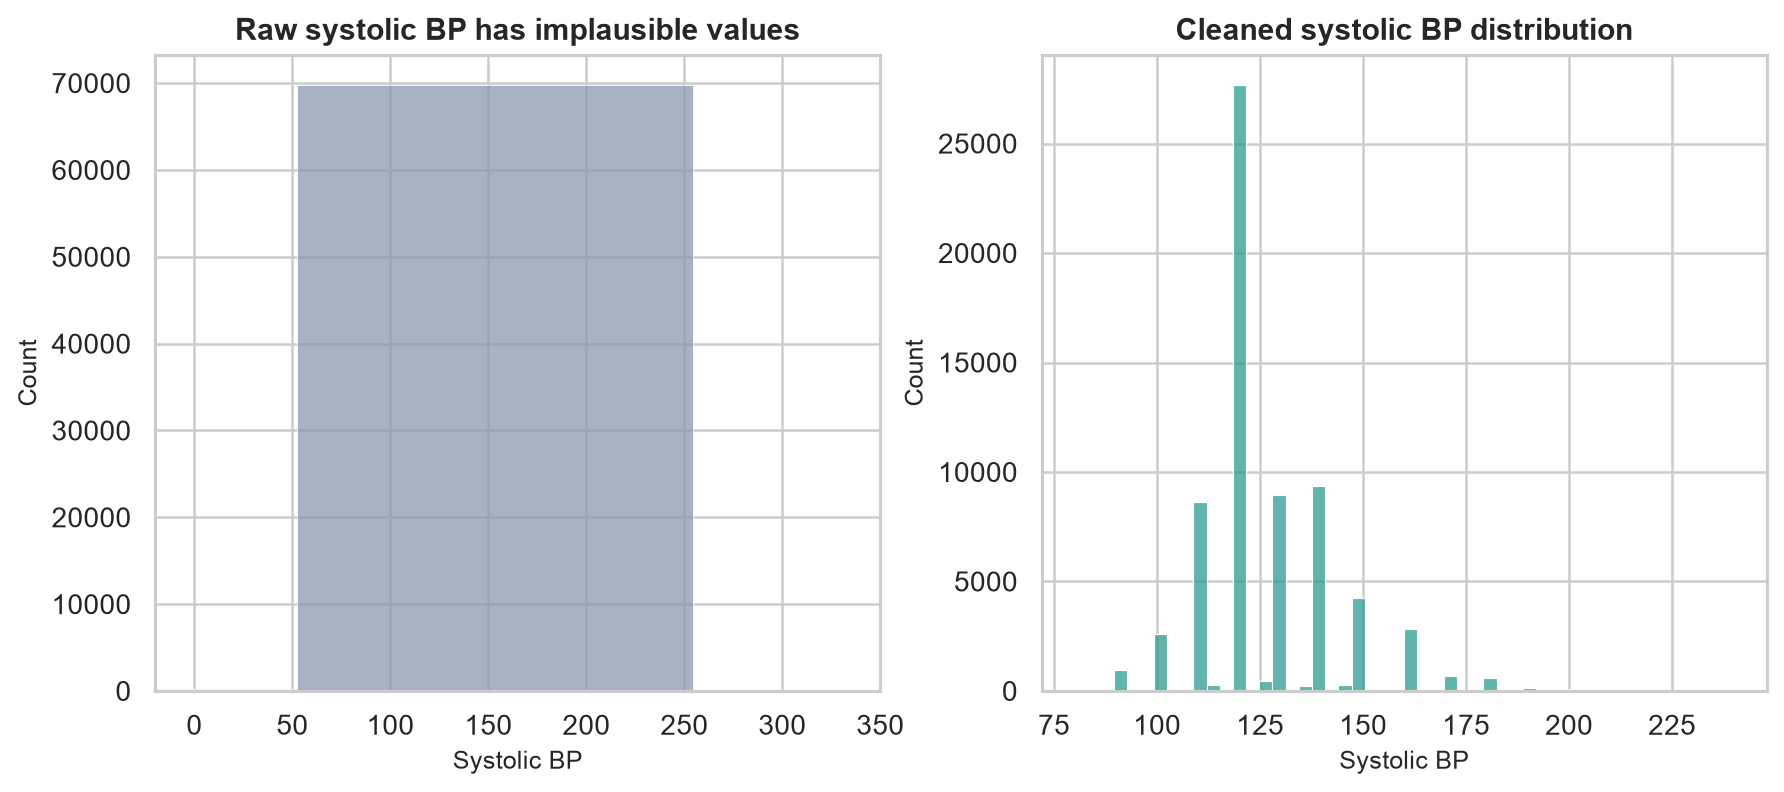

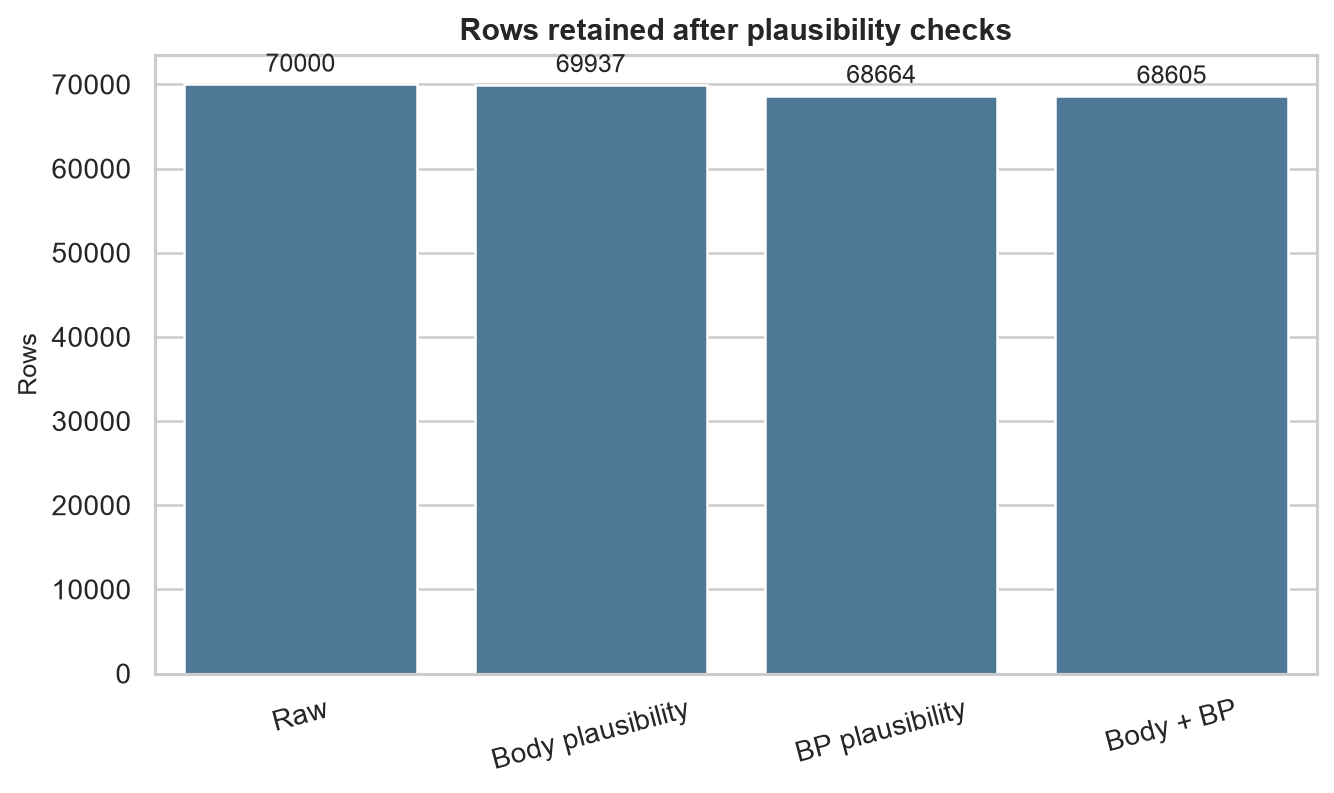

In [4]:
display(Image(filename=str(FIGURES / 'cardio_systolic_bp_raw_vs_clean.png')))
display(Image(filename=str(FIGURES / 'cardio_cleaning_flow.png')))

## 2. EDA: Risk Structure Is Present

After plausibility filtering, observed cardio-positive rate rises sharply with systolic blood-pressure band. This provides a sanity check that the target is aligned with recognizable cardiovascular risk factors.

In [5]:
pd.read_csv(TABLES / 'cardio_target_rate_by_systolic_band.csv')

,systolic_band,rows,target_rate
0,<120,12712,0.230491
1,120-129,28225,0.355996
2,130-139,9213,0.598502
3,>=140,18455,0.837009


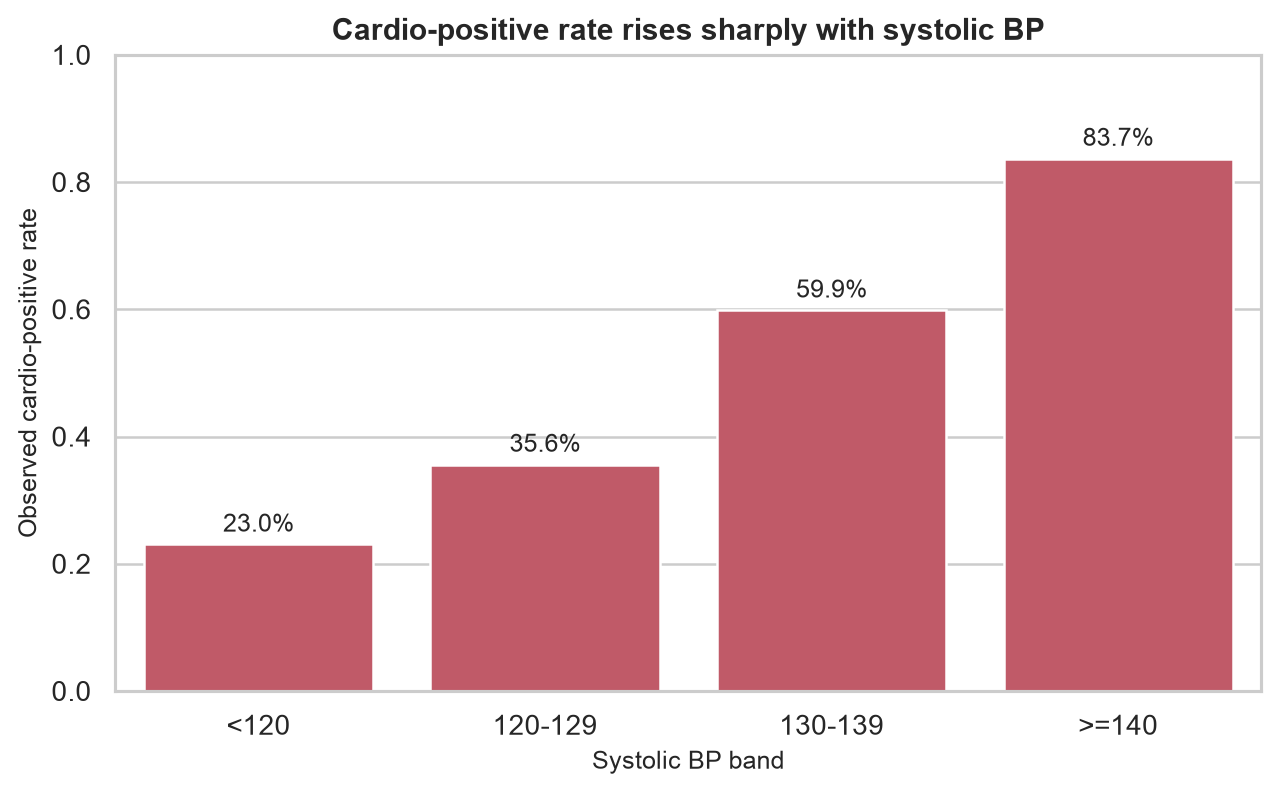

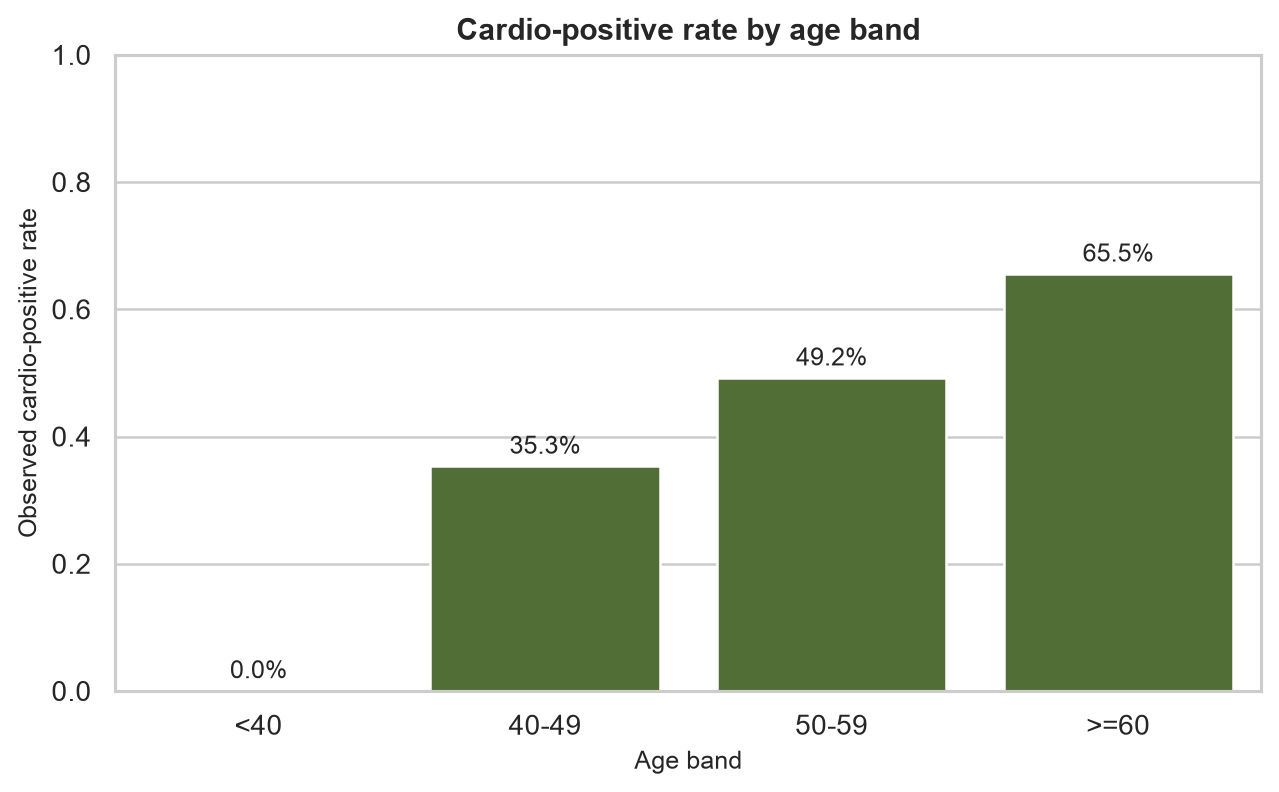

In [6]:
display(Image(filename=str(FIGURES / 'cardio_target_by_bp_band.png')))
display(Image(filename=str(FIGURES / 'cardio_target_by_age_band.png')))

## 3. Cleaning Sensitivity

A single cleaning rule can be arbitrary. We therefore compare raw, lenient, current, and strict cleaning profiles. The selected boosting model remains close to AUROC 0.80 across profiles, while raw implausible values hurt logistic regression more clearly.

In [7]:
pd.read_csv(TABLES / 'cleaning_sensitivity_summary.csv')

,profile,description,rows,rows_removed,removed_fraction,target_rate,age_mean,ap_hi_mean,ap_lo_mean,bmi_mean
0,raw,No plausibility filtering; included as a stres...,70000,0,0.000000,0.499700,53.302850,128.817286,96.630414,27.556513
1,lenient,Broad plausibility rules that remove extreme a...,68644,1356,0.019371,0.494726,53.291297,126.672703,81.302561,27.465911
2,current,Primary rules used in the current project base...,68605,1395,0.019929,0.494702,53.291843,126.672327,81.304147,27.454957
3,strict,Stricter sensitivity rules for robustness chec...,68362,1638,0.023400,0.495012,53.293222,126.694596,81.322109,27.432609


In [8]:
pd.read_csv(TABLES / 'cleaning_sensitivity_metrics.csv')[['cleaning_profile', 'model', 'rows', 'auroc', 'auprc', 'accuracy', 'brier']]

,cleaning_profile,model,rows,auroc,auprc,accuracy,brier
0,raw,logistic_l2,17500,0.777644,0.756450,0.712629,0.194763
1,raw,hist_gradient_boosting,17500,0.800401,0.784508,0.734229,0.180791
2,lenient,logistic_l2,17161,0.791681,0.772448,0.725948,0.186587
3,lenient,hist_gradient_boosting,17161,0.802540,0.785637,0.734922,0.180302
4,current,logistic_l2,17152,0.793051,0.774978,0.726737,0.186252
5,current,hist_gradient_boosting,17152,0.803693,0.789204,0.735541,0.179508
6,strict,logistic_l2,17091,0.789052,0.773311,0.726523,0.187493
7,strict,hist_gradient_boosting,17091,0.799130,0.779580,0.736938,0.180833


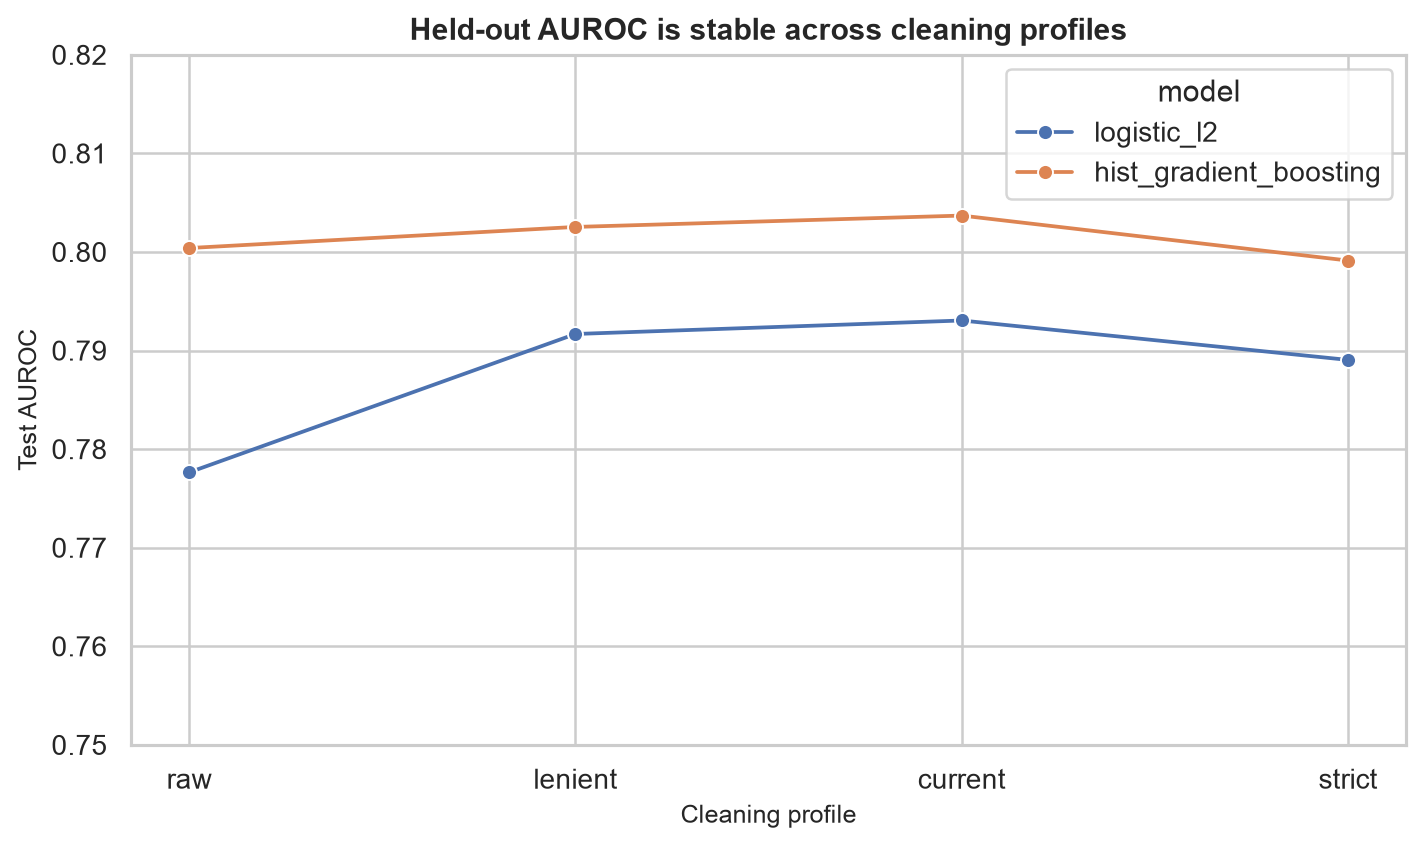

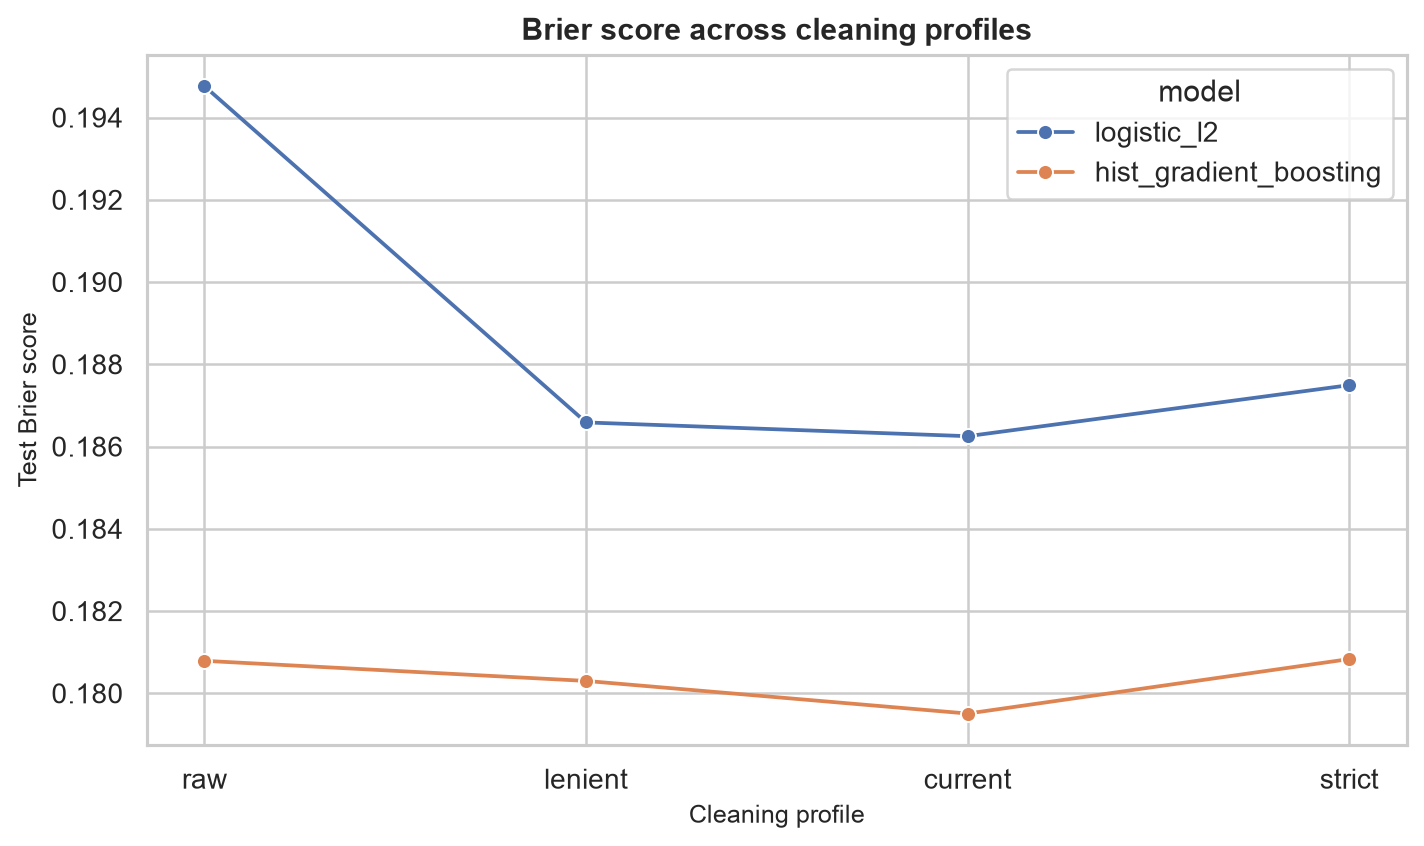

In [9]:
display(Image(filename=str(FIGURES / 'cleaning_sensitivity_auroc.png')))
display(Image(filename=str(FIGURES / 'cleaning_sensitivity_brier.png')))

## 4. Model Comparison

We compare a dummy prior, logistic regression, a shallow decision tree, random forest, and histogram gradient boosting. The selected model is histogram gradient boosting, but the improvement over random forest is small and the improvement over logistic regression is moderate. That is why the final story emphasizes reliability, calibration, and errors rather than model complexity alone.

In [10]:
model_results = pd.read_csv(TABLES / 'model_comparison.csv')
model_results[model_results['split'].eq('test')][['dataset', 'model', 'rows', 'auroc', 'auprc', 'accuracy', 'brier', 'sensitivity', 'specificity']].sort_values(['dataset', 'auroc'], ascending=[True, False])

,dataset,model,rows,auroc,auprc,accuracy,brier,sensitivity,specificity
9,cardio_clean,hist_gradient_boosting,17152,0.803693,0.789204,0.735541,0.179508,0.687566,0.782508
7,cardio_clean,random_forest,17152,0.802437,0.787545,0.735483,0.180081,0.692752,0.777316
3,cardio_clean,logistic_l2,17152,0.793051,0.774978,0.726737,0.186252,0.667531,0.784701
5,cardio_clean,decision_tree_depth4,17152,0.787580,0.759776,0.729594,0.184438,0.719034,0.739933
1,cardio_clean,dummy_prior,17152,0.500000,0.494694,0.505306,0.249972,0.000000,1.000000
19,heart_processed,hist_gradient_boosting,230,0.941289,0.937450,0.886957,0.092286,0.889764,0.883495
13,heart_processed,logistic_l2,230,0.934485,0.938591,0.891304,0.092312,0.913386,0.864078
17,heart_processed,random_forest,230,0.928522,0.935248,0.843478,0.112578,0.905512,0.766990
15,heart_processed,decision_tree_depth4,230,0.840914,0.812089,0.791304,0.152266,0.811024,0.766990
11,heart_processed,dummy_prior,230,0.500000,0.552174,0.552174,0.247280,1.000000,0.000000


In [11]:
pd.read_csv(TABLES / 'cross_validation_summary.csv').sort_values(['dataset', 'cv_auroc_mean'], ascending=[True, False])

,dataset,model,cv_folds,cv_auroc_mean,cv_auroc_std,cv_auprc_mean,cv_auprc_std,cv_accuracy_mean,cv_accuracy_std,cv_brier_mean,cv_log_loss_mean
4,cardio_clean,hist_gradient_boosting,5,0.801348,0.002491,0.784309,0.003285,0.734509,0.001095,0.180469,0.540913
3,cardio_clean,random_forest,5,0.800745,0.002476,0.783732,0.003067,0.735136,0.002346,0.180877,0.542048
1,cardio_clean,logistic_l2,5,0.791178,0.002585,0.770629,0.004768,0.726944,0.001743,0.187013,0.560598
2,cardio_clean,decision_tree_depth4,5,0.786350,0.003287,0.755707,0.005291,0.728387,0.002141,0.185027,0.552718
0,cardio_clean,dummy_prior,5,0.500000,0.000000,0.494702,0.000029,0.505298,0.000029,0.249972,0.693091
6,heart_processed,logistic_l2,5,0.927942,0.016014,0.935314,0.017471,0.870355,0.019418,0.102363,0.337584
9,heart_processed,hist_gradient_boosting,5,0.919604,0.019636,0.922395,0.017944,0.857294,0.019902,0.113287,0.450992
8,heart_processed,random_forest,5,0.919401,0.027137,0.926312,0.027617,0.848586,0.026524,0.115073,0.379609
7,heart_processed,decision_tree_depth4,5,0.870468,0.028974,0.856171,0.031992,0.813732,0.022669,0.138970,0.442712
5,heart_processed,dummy_prior,5,0.500000,0.000000,0.553374,0.001193,0.553374,0.001193,0.247152,0.687440


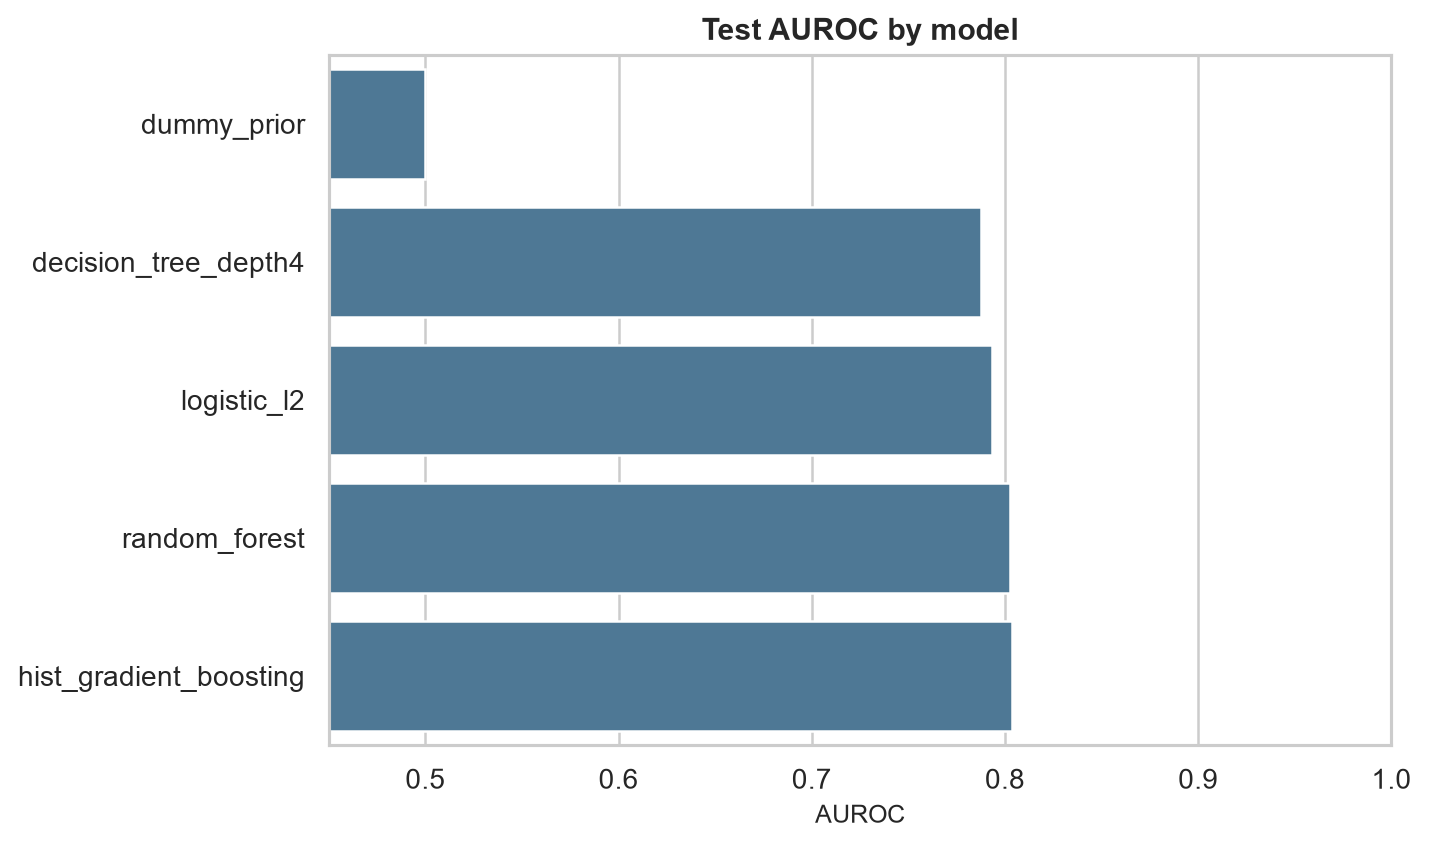

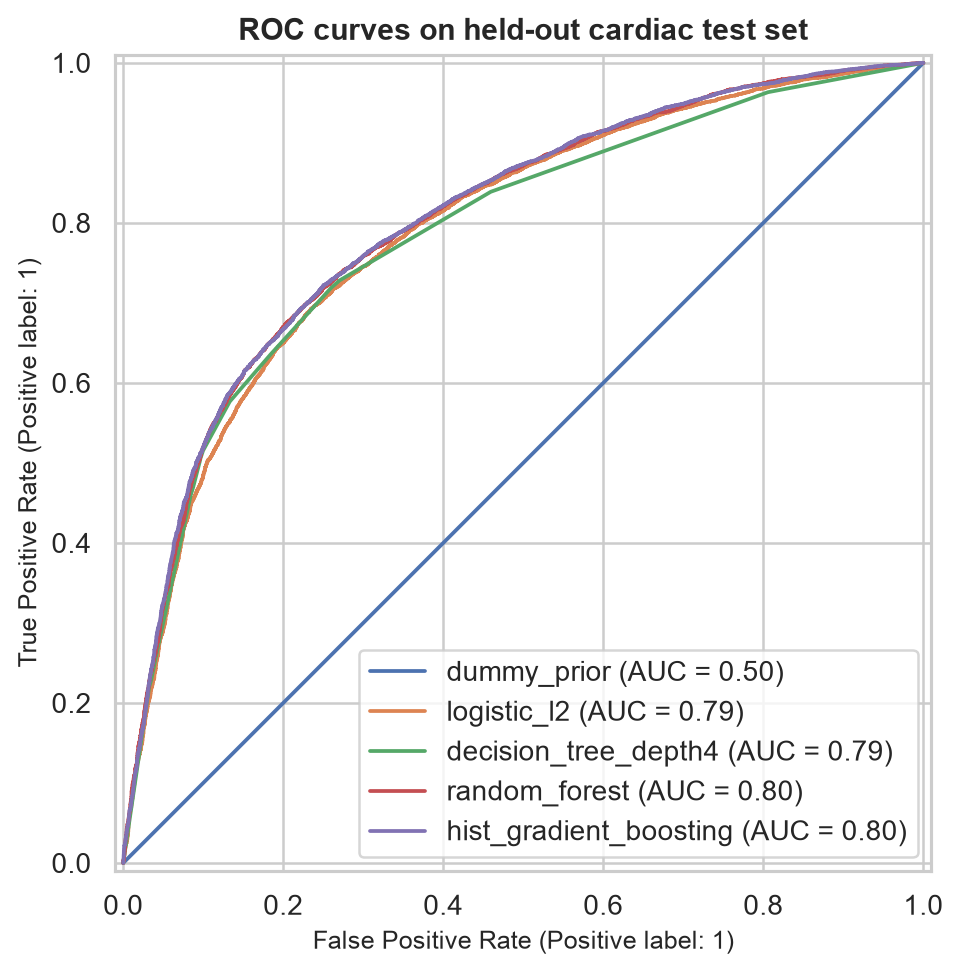

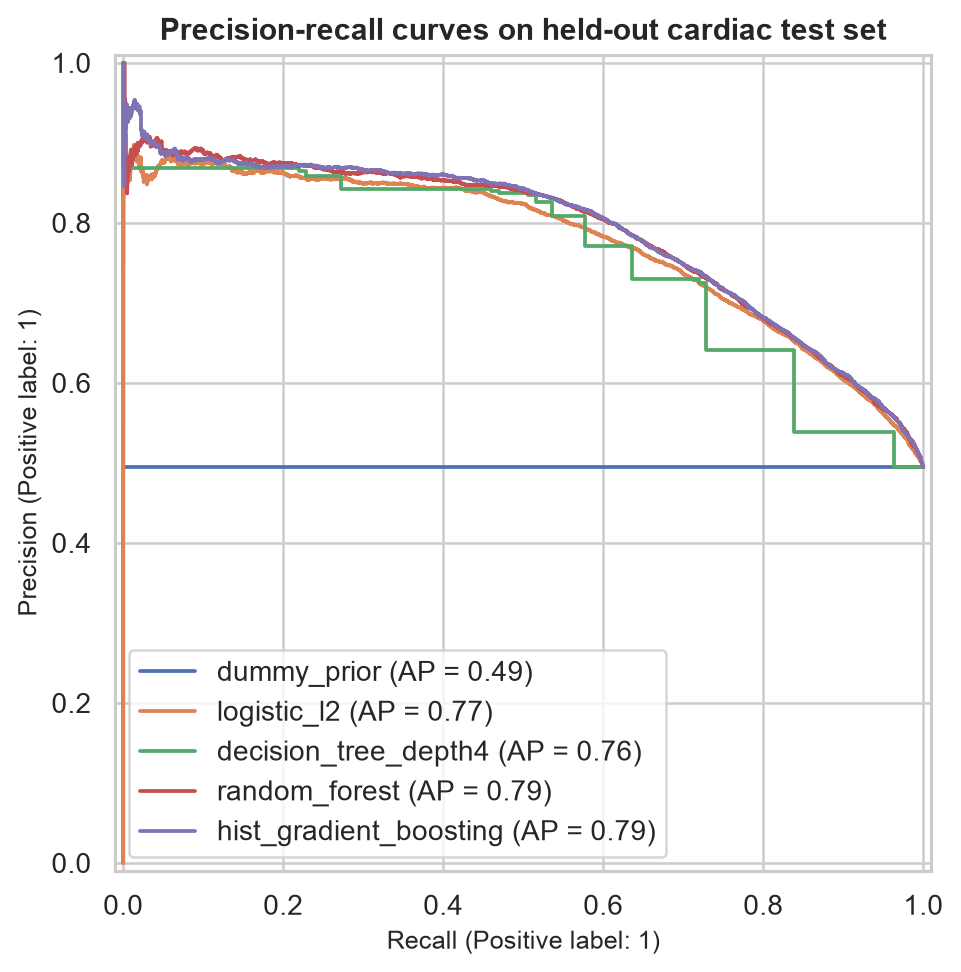

In [12]:
display(Image(filename=str(FIGURES / 'model_comparison_auroc.png')))
display(Image(filename=str(FIGURES / 'roc_curves.png')))
display(Image(filename=str(FIGURES / 'pr_curves.png')))

## 5. Uncertainty and Threshold Analysis

The selected model is evaluated with bootstrap intervals on the held-out predictions and with a threshold grid. This separates model discrimination from operating-point choice: changing the threshold can reduce false negatives or false positives, but it cannot make both disappear.

In [13]:
bootstrap_ci = pd.read_csv(TABLES / 'selected_model_bootstrap_ci.csv')
bootstrap_ci[['metric', 'point_estimate', 'ci_lower_95', 'ci_upper_95', 'bootstrap_iterations']]

,metric,point_estimate,ci_lower_95,ci_upper_95,bootstrap_iterations
0,accuracy,0.735541,0.728953,0.742537,2000
1,auprc,0.789204,0.779567,0.798995,2000
2,auroc,0.803693,0.797020,0.810302,2000
3,brier,0.179508,0.176467,0.182530,2000
4,sensitivity,0.687566,0.677847,0.697497,2000
5,specificity,0.782508,0.773962,0.791623,2000


In [14]:
threshold_summary = pd.read_csv(TABLES / 'selected_model_threshold_summary.csv')
threshold_summary[['operating_point', 'threshold', 'precision', 'sensitivity', 'specificity', 'f1', 'fp', 'fn']]

,operating_point,threshold,precision,sensitivity,specificity,f1,fp,fn
0,default_threshold_0_50,0.50,0.755797,0.687566,0.782508,0.720069,1885,2651
1,max_f1,0.35,0.661085,0.832882,0.581978,0.737106,3623,1418
2,max_accuracy,0.50,0.755797,0.687566,0.782508,0.720069,1885,2651
3,sensitivity_at_least_0_80_lowest_fp,0.35,0.661085,0.832882,0.581978,0.737106,3623,1418
4,specificity_at_least_0_80_lowest_fn,0.55,0.779661,0.645138,0.821507,0.706049,1547,3011


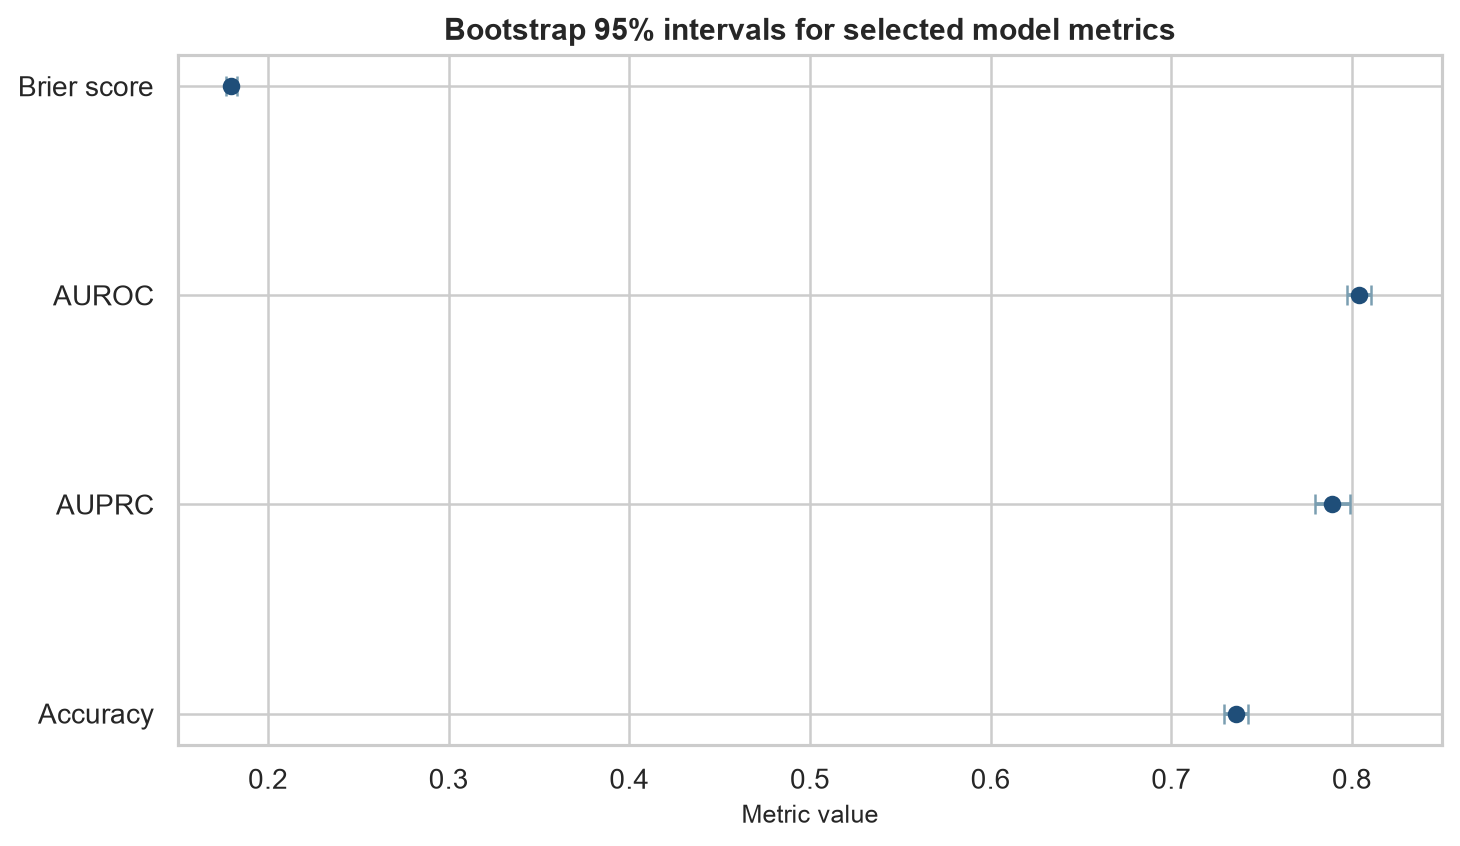

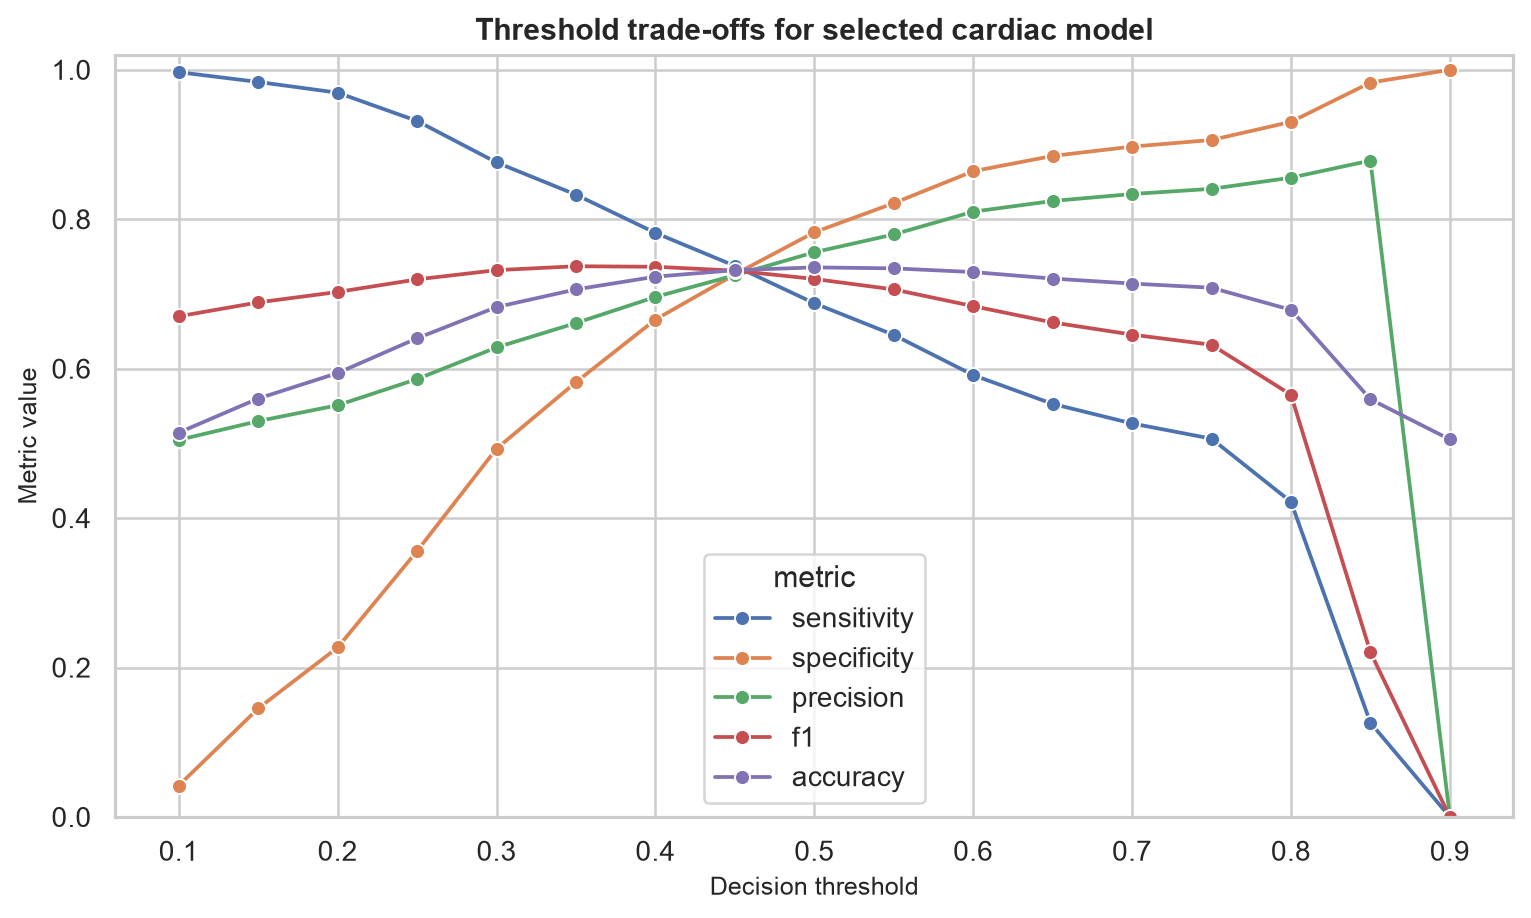

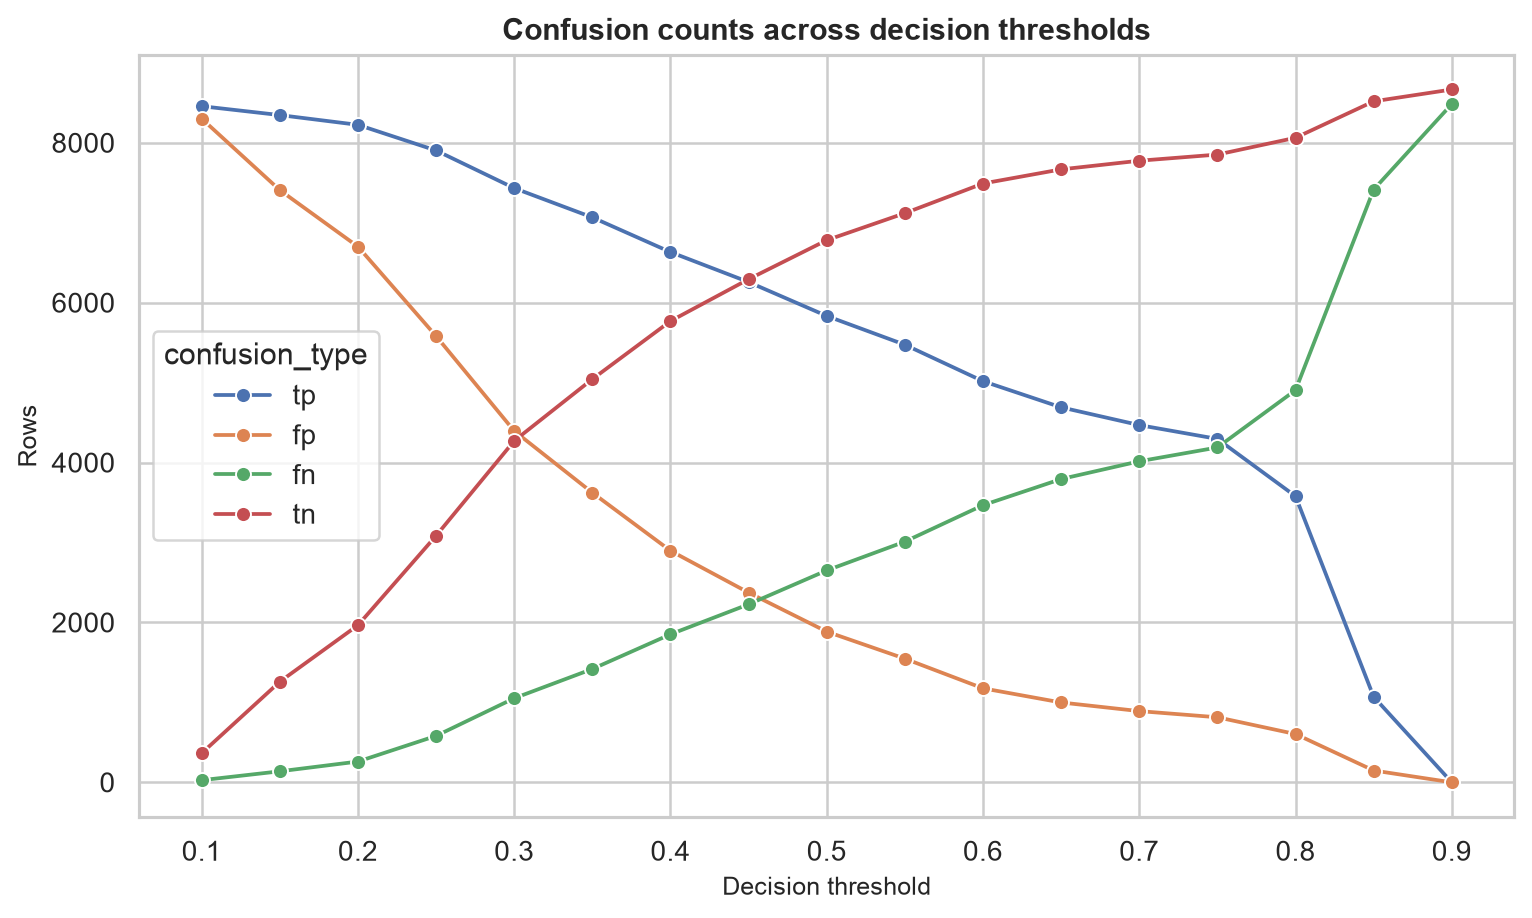

In [15]:
display(Image(filename=str(FIGURES / 'selected_model_bootstrap_ci.png')))
display(Image(filename=str(FIGURES / 'selected_model_threshold_tradeoff.png')))
display(Image(filename=str(FIGURES / 'selected_model_threshold_counts.png')))

## 6. Calibration

Risk models should be checked as probability estimators, not only ranking functions. The selected model is reasonably aligned in calibration bins, though this is still an educational public-data analysis rather than a deployment-ready clinical tool.

In [16]:
pd.read_csv(TABLES / 'cardio_clean_calibration_bins.csv')

,dataset,model,rows,mean_predicted_risk,observed_rate,min_predicted_risk,max_predicted_risk,abs_calibration_error
0,cardio_clean,hist_gradient_boosting,1717,0.121397,0.110076,0.043974,0.171463,0.011322
1,cardio_clean,hist_gradient_boosting,1714,0.213240,0.192532,0.171471,0.243480,0.020708
2,cardio_clean,hist_gradient_boosting,1715,0.268551,0.286297,0.243487,0.295411,0.017746
3,cardio_clean,hist_gradient_boosting,1715,0.330658,0.325948,0.295412,0.365010,0.004711
4,cardio_clean,hist_gradient_boosting,1715,0.405582,0.395335,0.365175,0.453433,0.010247
5,cardio_clean,hist_gradient_boosting,1715,0.503209,0.497376,0.453601,0.563389,0.005833
6,cardio_clean,hist_gradient_boosting,1716,0.627896,0.622378,0.563451,0.743182,0.005519
7,cardio_clean,hist_gradient_boosting,1718,0.792840,0.793364,0.743226,0.814203,0.000525
8,cardio_clean,hist_gradient_boosting,1711,0.826182,0.854471,0.814215,0.841038,0.028290
9,cardio_clean,hist_gradient_boosting,1716,0.857803,0.869464,0.841058,0.891476,0.011661


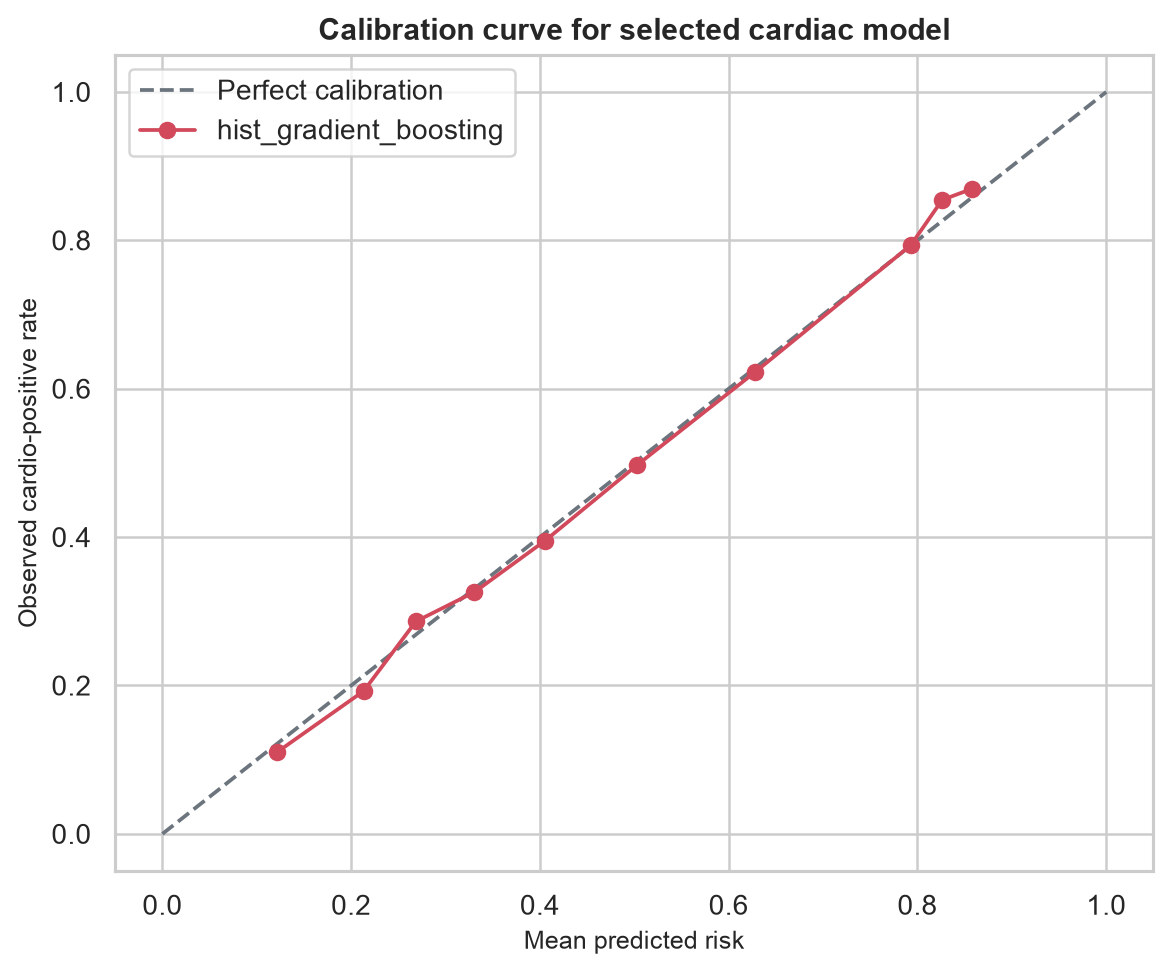

In [17]:
display(Image(filename=str(FIGURES / 'calibration_curve.png')))

## 7. Interpretability

The logistic baseline and permutation importance indicate that the model is mostly learning classic cardiovascular risk structure: blood pressure, cholesterol, age, and related body/lifestyle features. These are predictive associations, not causal claims.

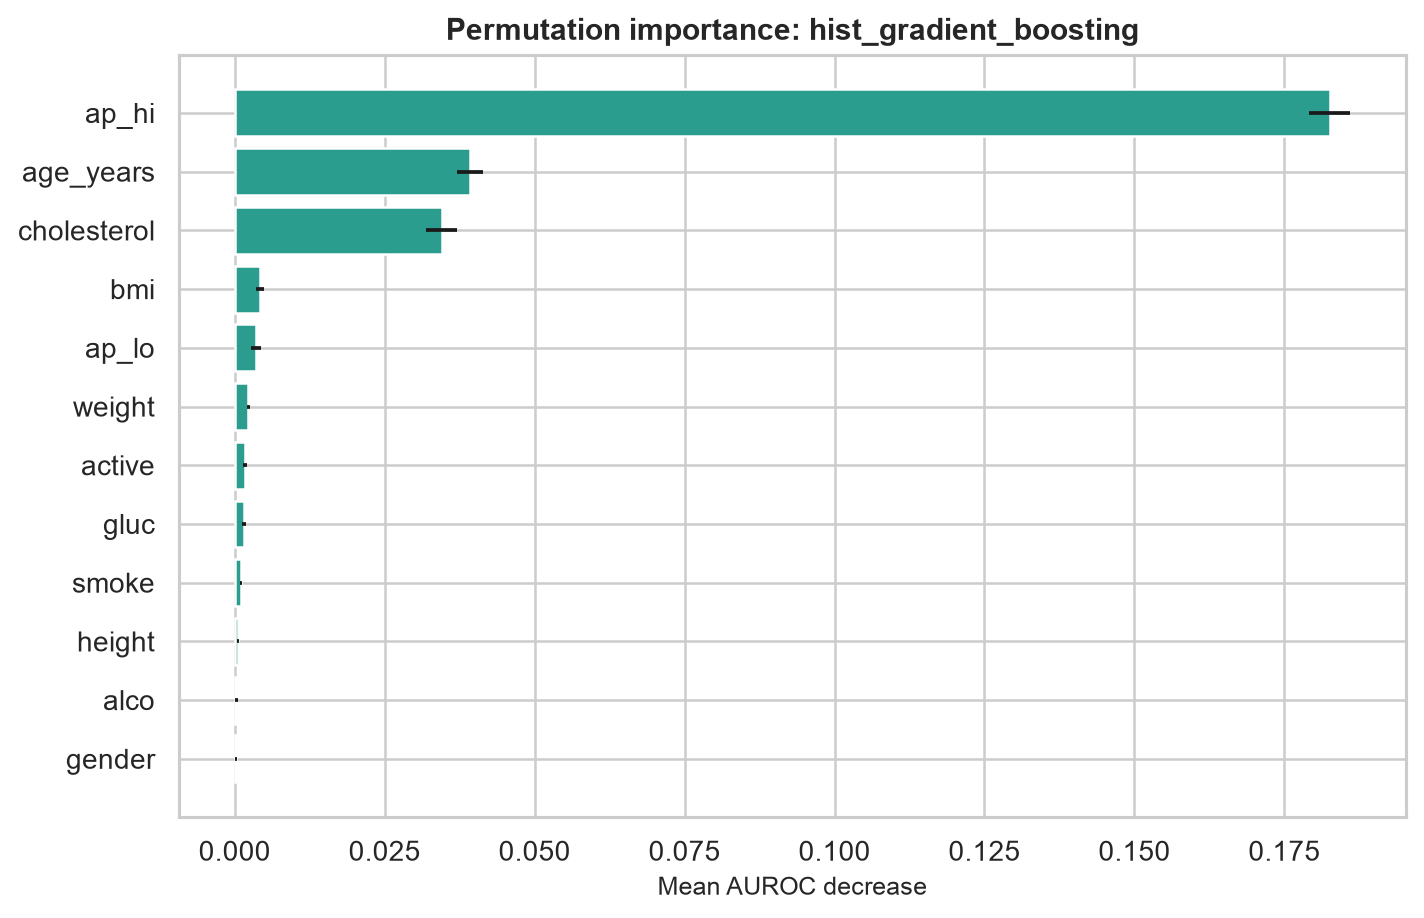

,dataset,model,feature,importance_mean,importance_std
0,cardio_clean,hist_gradient_boosting,ap_hi,0.182562,0.003409
1,cardio_clean,hist_gradient_boosting,age_years,0.039178,0.002173
2,cardio_clean,hist_gradient_boosting,cholesterol,0.034535,0.002576
3,cardio_clean,hist_gradient_boosting,bmi,0.004191,0.000703
4,cardio_clean,hist_gradient_boosting,ap_lo,0.003540,0.000780
5,cardio_clean,hist_gradient_boosting,weight,0.002267,0.000212
6,cardio_clean,hist_gradient_boosting,active,0.001662,0.000333
7,cardio_clean,hist_gradient_boosting,gluc,0.001493,0.000334
8,cardio_clean,hist_gradient_boosting,smoke,0.001044,0.000187
9,cardio_clean,hist_gradient_boosting,height,0.000530,0.000134


In [18]:
display(Image(filename=str(FIGURES / 'feature_importance.png')))
pd.read_csv(TABLES / 'feature_importance.csv').head(12)

## 8. Error Analysis: Where The Model Fails

The selected model is asymmetric. It often misses actual positives who look lower-risk by systolic BP, and it overcalls the minority of high-BP / high-cholesterol negatives. This is clinically intuitive, but it is exactly why aggregate AUROC is not enough.

In [19]:
pd.read_csv(TABLES / 'error_analysis_summary.csv')

,error_type,rows,share,mean_predicted_risk,mean_age,mean_systolic_bp,mean_diastolic_bp,mean_bmi,mean_cholesterol,active_rate,smoke_rate
0,TN,6782,0.395406,0.268678,50.442905,115.781628,76.319080,25.719258,1.110882,0.842082,0.100265
1,FP,1885,0.109900,0.687224,56.683094,133.424934,85.024403,29.095820,1.587268,0.747480,0.068435
2,FN,2651,0.154559,0.333615,52.930785,118.132026,77.748020,26.355096,1.165975,0.812524,0.084874
3,TP,5834,0.340135,0.768478,55.825982,141.217175,87.925437,29.364622,1.670552,0.774426,0.090675


In [20]:
pd.read_csv(TABLES / 'error_analysis_by_group.csv')[['group_col', 'group_value', 'rows', 'positive_rate', 'accuracy', 'fp_rate_among_negatives', 'fn_rate_among_positives']].head(20)

,group_col,group_value,rows,positive_rate,accuracy,fp_rate_among_negatives,fn_rate_among_positives
0,bp_band,<120,3050,0.226557,0.786230,0.024587,0.859624
1,bp_band,120-129,7179,0.352556,0.677671,0.108219,0.715527
2,bp_band,130-139,2345,0.598294,0.636674,0.643312,0.175339
3,bp_band,>=140,4578,0.843163,0.843163,1.000000,0.000000
4,age_band,<40,1,0.000000,1.000000,0.000000,NaN
5,age_band,40-49,4320,0.356713,0.808102,0.070889,0.410123
6,age_band,50-59,8738,0.491417,0.715381,0.200945,0.371216
7,age_band,>=60,4093,0.647447,0.701930,0.550936,0.160377
8,gender,1,11057,0.492810,0.736818,0.216655,0.311066
9,gender,2,6095,0.498113,0.733224,0.219026,0.314888


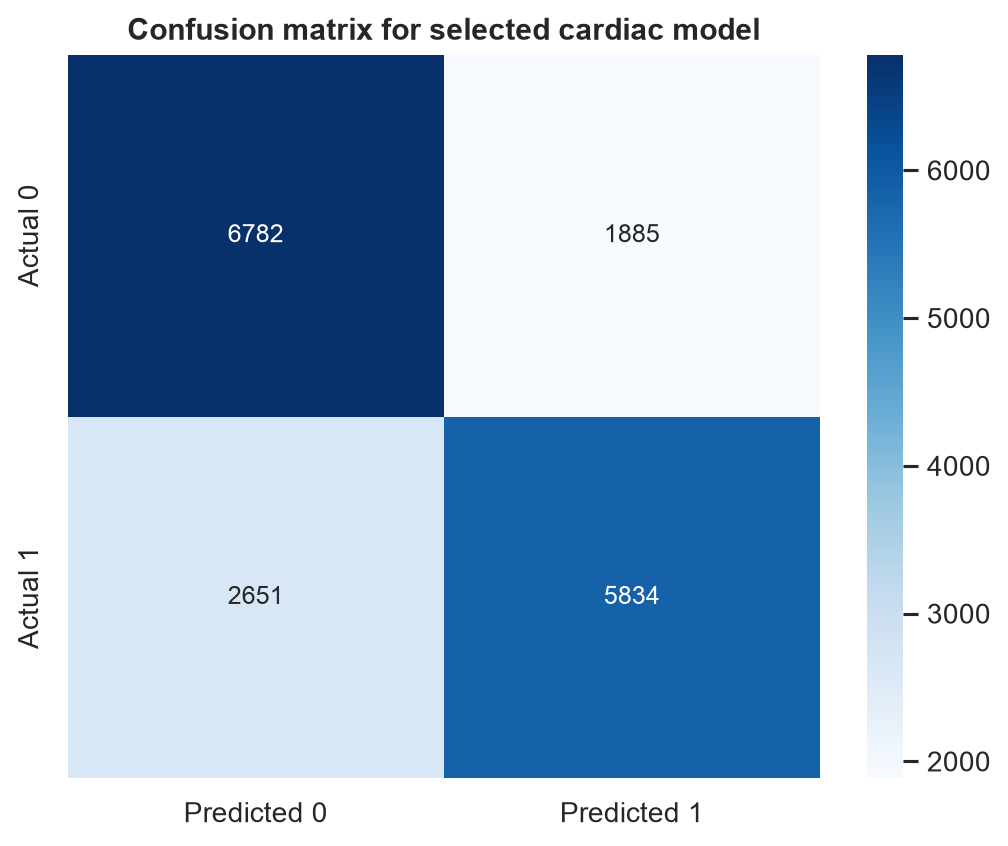

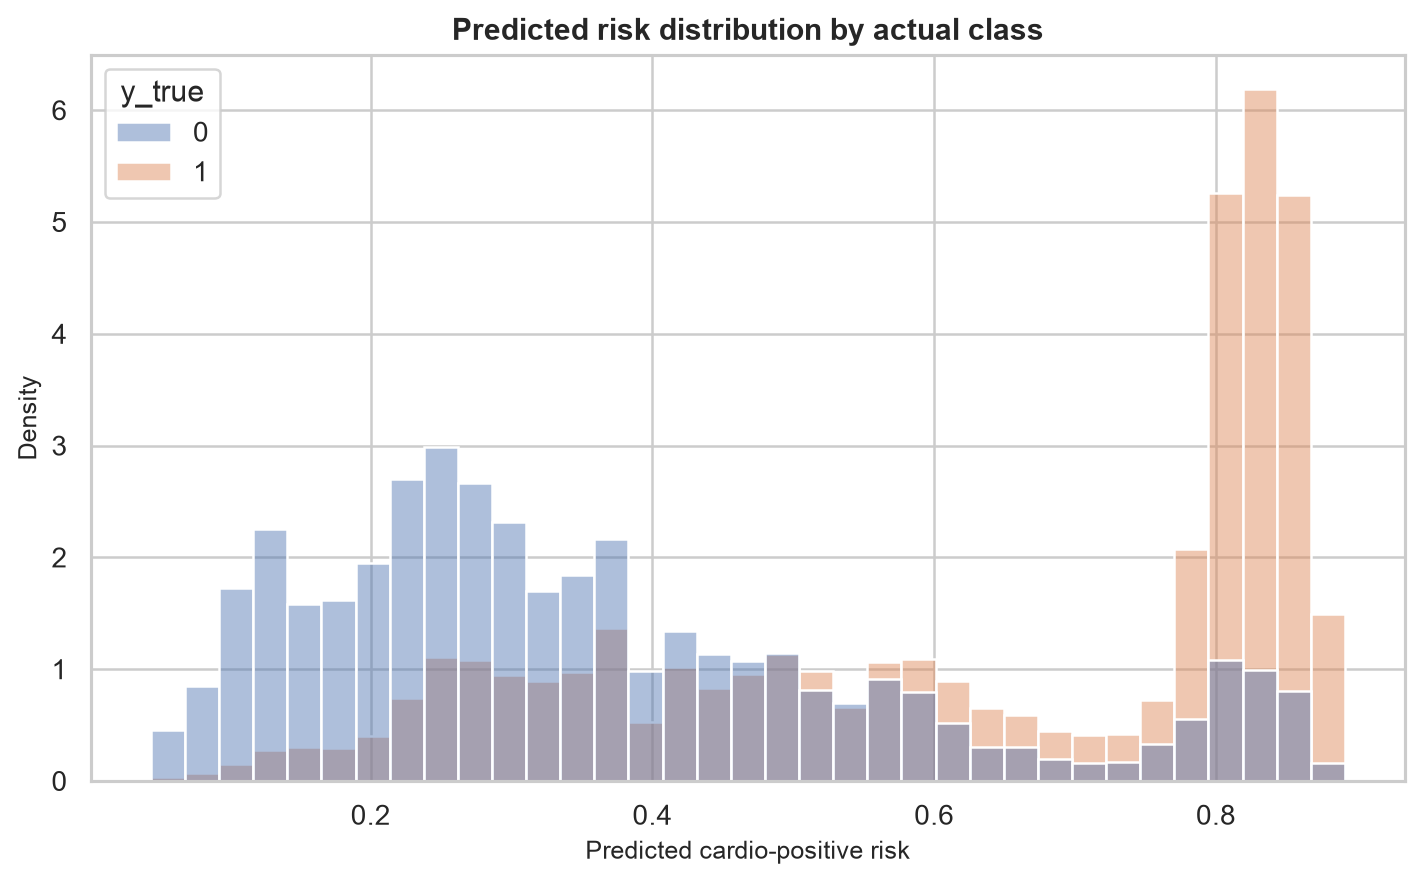

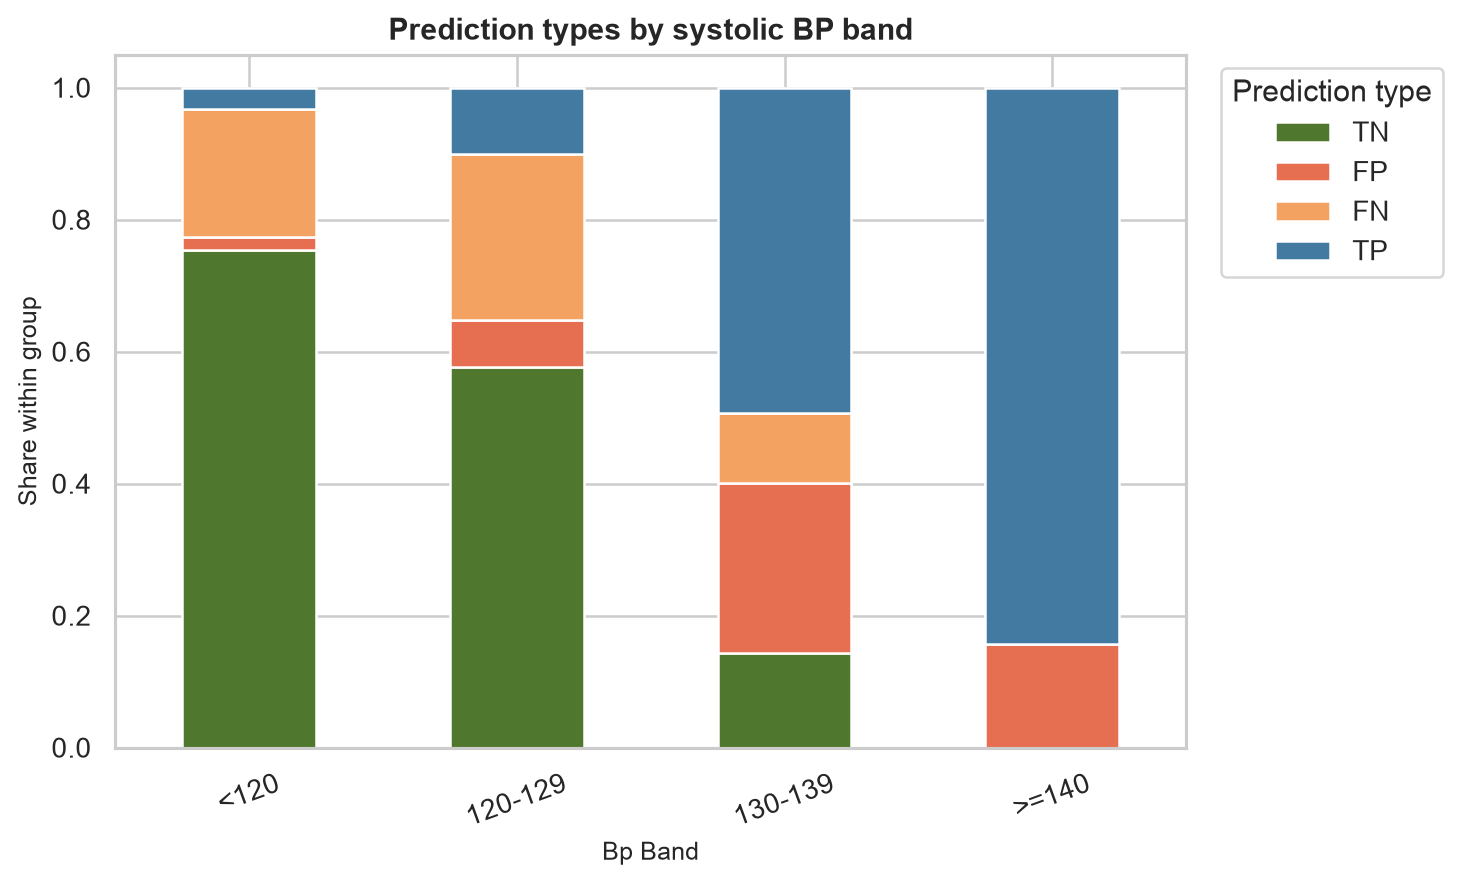

In [21]:
display(Image(filename=str(FIGURES / 'error_confusion_matrix.png')))
display(Image(filename=str(FIGURES / 'error_prediction_distribution.png')))
display(Image(filename=str(FIGURES / 'error_type_by_bp_band.png')))

## 9. ECG Gate

The ECG file is not used as a headline supervised result. A lightweight schema audit found 528 rows, 123,995 columns, and 36,441 duplicate non-empty header names. Without validated row semantics and labels, using ECG for a headline model would weaken the scientific claim.

In [22]:
pd.read_json(TABLES / 'ecg_schema_audit.json', typ='series')

path                               docs/drive-download-20260627T215828Z-3-001/Dat...
file_size_mb                                                              626.955871
header_len                                                                    123995
row_count                                                                        528
row_lengths                                                          {'123995': 528}
first_header                                    [, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
last_header                        [4033, 4034, 4035, 4036, 4037, 4038, 4039, 404...
duplicate_nonempty_header_count                                                36441
first_repeated_header_names        [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...
first_rows_excerpt                 [[1.000000000000000000e+00, 0.9084249138832092...
sampled_numeric_values                                                         66000
sampled_min                                                      

## 10. Conclusion

The cleaned cardiac dataset supports a stable risk-prediction baseline around AUROC 0.80. Histogram gradient boosting and random forest slightly outperform logistic regression, but the main contribution is the workflow: data audit, transparent plausibility checks, sensitivity analysis, calibration, interpretability, and explicit error analysis.

**Final claim:** public cardiovascular ML projects should report not only model score, but also data quality decisions and failure modes.

**Limitations:** dataset-specific targets, public-data representativeness, predictive association rather than causation, no clinical deployment claim, and meaningful subgroup errors.